# MotoGP Datathon: Lap Time Prediction 

Welcome to this notebook for the MotoGP Datathon, focused on predicting lap times! In this competition, our goal is to leverage various rider, bike, and circuit characteristics to accurately forecast the time it takes for a MotoGP rider to complete a lap.

Predicting lap times is crucial in motorsport for strategy optimization, performance analysis, and understanding competitive dynamics.

---

## 1. Initial Setup and Data Loading 

We begin by importing the necessary libraries for data manipulation and numerical operations. Then, we load the training, testing, and sample submission datasets provided for the competition.

-   `pandas` is indispensable for data handling and analysis.
-   `numpy` provides powerful numerical computing capabilities, especially useful for array operations.

Let's load the datasets and take a first look at their structure and the initial rows of the training data.

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/burnout-datathon-ieeecsmuj/train.csv')
test = pd.read_csv('/kaggle/input/burnout-datathon-ieeecsmuj/test.csv')
sample = pd.read_csv('/kaggle/input/burnout-datathon-ieeecsmuj/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1914056, 45)
Test shape: (546874, 44)


,Unique ID,Rider_ID,category_x,Circuit_Length_km,Laps,Grid_Position,Avg_Speed_kmh,Track_Condition,Humidity_%,Tire_Compound_Front,...,air,ground,starts,finishes,with_points,podiums,wins,min_year,max_year,years_active
0,1894944,2659,Moto2,4.874,22,17,264.66,Wet,61,Hard,...,23,35,53,45,41,4,0,2018,2021,4
1,23438,5205,Moto2,3.875,24,7,177.56,Wet,77,Soft,...,12,12,27,27,22,2,1,1975,1983,8
2,939678,7392,Moto3,5.647,25,5,317.74,Dry,87,Soft,...,22,23,45,43,10,0,0,1982,1989,8
3,1196312,7894,Moto3,4.810,19,3,321.82,Wet,43,Soft,...,23,35,192,172,155,16,9,1994,2009,16
4,1033899,6163,MotoGP,5.809,25,21,239.92,Wet,47,Hard,...,22,31,175,146,132,29,17,2011,2021,11


## 2. Suppressing Warnings 
To keep our notebook output clean and focused on essential information, we'll suppress common warnings, such as **DeprecationWarning** and **UserWarning**, which often arise from library updates or specific function usages. This helps improve readability without affecting the core logic.

In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## 3. Exploratory Data Analysis (EDA) 
A quick look at our data to understand its shape and key characteristics.

**2.1 Target Variable (Lap_Time_Seconds)**
Let's check the distribution of our target variable, Lap_Time_Seconds.

- Observation: (Describe what you see: e.g., "Mostly normal distribution, slightly skewed towards higher times.")


**2.2 Missing Values**
Identifying any missing data is crucial for pre-processing.

- Observation: (State the finding: e.g., "Some features have nulls, which will need handling," or "Data is largely complete.")


**2.3 Feature Correlation with Lap_Time_Seconds**
Understanding which features strongly influence Lap_Time_Seconds helps in feature selection.

- Observation: (Summarize key correlations: e.g., "Strong inverse correlation with Speed, positive with Tyre_Wear - intuitive!")


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


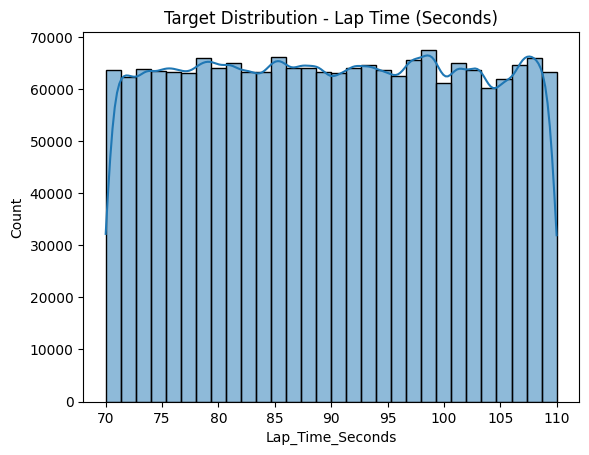

Missing values:
 Penalty              321292
Rider_ID                  0
category_x                0
Circuit_Length_km         0
Unique ID                 0
Laps                      0
Grid_Position             0
Track_Condition           0
Avg_Speed_kmh             0
Humidity_%                0
dtype: int64


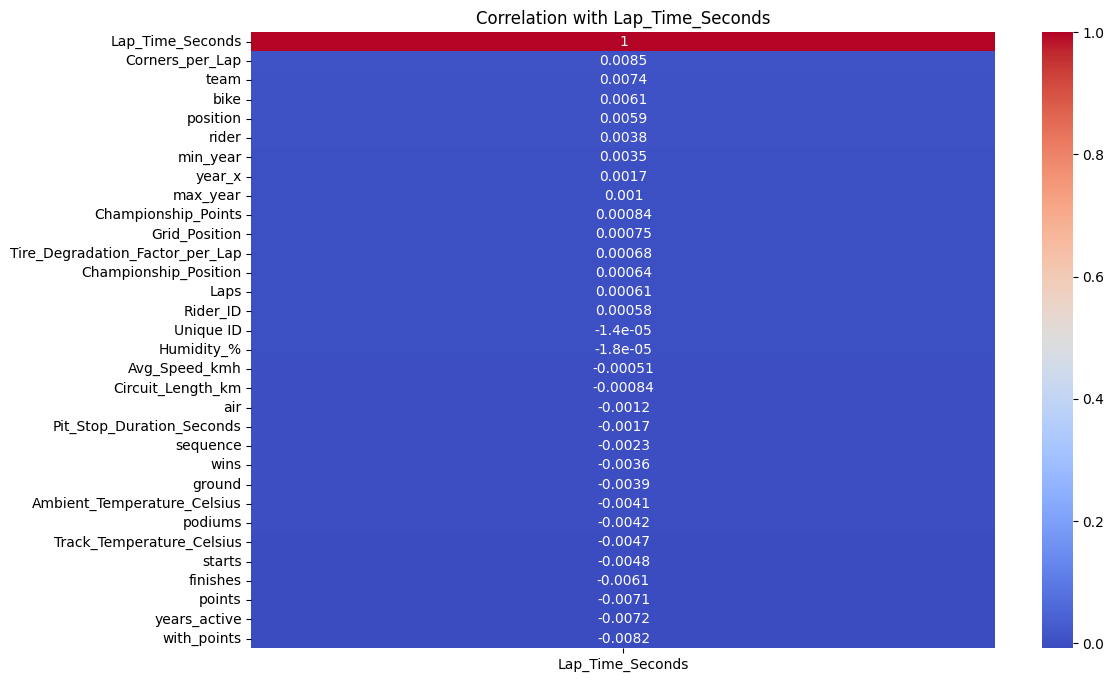

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target Distribution
sns.histplot(train['Lap_Time_Seconds'], kde=True, bins=30)
plt.title("Target Distribution - Lap Time (Seconds)")
plt.show()

# Null Count
print("Missing values:\n", train.isnull().sum().sort_values(ascending=False).head(10))


numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
corr = train[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr[['Lap_Time_Seconds']].sort_values(by='Lap_Time_Seconds', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation with Lap_Time_Seconds")
plt.show()

## 4. Setup & Data Preparation 
Here, we set up our environment by installing necessary library versions, importing core tools, and defining key column names and data paths. This ensures reproducibility and prepares our data for modeling.

**Key Action:** We're explicitly installing specific versions of xgboost and pandas for environment consistency.

**Purpose:** This block is the foundation for our modeling pipeline, ensuring all required modules are available and data is loaded correctly for the next steps.

In [5]:
!pip install --quiet xgboost==2.0.3 pandas==2.2.2

import pandas as pd, numpy as np, os, xgboost as xgb, time, gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Paths & column names
DATA_DIR = "/kaggle/input/burnout-datathon-ieeecsmuj"   
TARGET   = "Lap_Time_Seconds"                
ID_COL   = "Unique ID"                       

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
print("Train shape:", train_df.shape, "  Test shape:", test_df.shape)

Train shape: (1914056, 45)   Test shape: (546874, 44)


## 5. Feature Engineering
To enhance our model's predictive power, we're creating a few new features from the existing ones. This process, known as feature engineering, helps capture more complex relationships within the data.

### New Features Created:
- **secs_per_km:** Derived from *Circuit_Length_km* and *Avg_Speed_kmh*, this feature aims to capture the average time spent per kilometer, which is a direct indicator of speed relative to track length.

- **track_minus_air:** The difference between *Track_Temperature_Celsius* and *Ambient_Temperature_Celsius*. This could be important as tire grip and engine performance can be sensitive to the temperature differential between the track surface and the surrounding air.
  
- **is_wet:** A binary (0/1) flag indicating if the *Track_Condition* is "Wet". Wet conditions drastically alter lap times, so this explicit feature is crucial.

- **tire_combo:** A categorical feature created by concatenating *Tire_Compound_Front* and *Tire_Compound_Rear*. The combination of front and rear tires is a key strategic choice affecting performance.


These features are expected to provide more direct and relevant information for predicting lap times.

In [6]:
# Minimal feature engineering
def add_features(df):
    if {"Circuit_Length_km", "Avg_Speed_kmh"}.issubset(df.columns):
        df["secs_per_km"] = (df["Circuit_Length_km"] / df["Avg_Speed_kmh"]) * 3600
    if {"Track_Temperature_Celsius", "Ambient_Temperature_Celsius"}.issubset(df.columns):
        df["track_minus_air"] = df["Track_Temperature_Celsius"] - df["Ambient_Temperature_Celsius"]
    if "Track_Condition" in df.columns:
        df["is_wet"] = df["Track_Condition"].str.contains("Wet", case=False, na=False).astype(int)
    if {"Tire_Compound_Front", "Tire_Compound_Rear"}.issubset(df.columns):
        df["tire_combo"] = df["Tire_Compound_Front"].fillna("") + "_" + df["Tire_Compound_Rear"].fillna("")
    return df

train_df = add_features(train_df);  test_df = add_features(test_df)

## 6. Feature Transformation: Position
We're converting the *position* feature from a numeric type to a categorical string. This ensures that our model treats *position* as distinct categories rather than a continuous numerical value, which is often more appropriate for ranks or discrete placings. The original numeric *position* column is then dropped.

**Why ?** 

Treating position as a category (e.g., '1st', '2nd') rather than a number (1, 2) can better represent its true impact, as the difference between 1st and 2nd might not be the same as between 10th and 11th in a purely numerical sense.

In [7]:
# Convert position numeric → categorical string (if present)
if "position" in train_df.columns:
    train_df["Position_cat"] = train_df["position"].astype(str)
    test_df["Position_cat"]  = test_df["position"].astype(str)
    train_df.drop(columns=["position"], inplace=True)
    test_df.drop(columns=["position"],  inplace=True)

## 7. Feature Type Identification & Missing Value Imputation
Before training, we accurately identify categorical and numerical features and handle any missing values. This ensures our data is clean and in the correct format for the model.

**Key Steps:**

- **Categorical/Numerical Split:** Features are separated based on their data types.
- **Consistency Check:** Only categorical columns present in both train and test sets are kept to avoid issues.

- **NaN Imputation:**
  
-- 1. Categorical missing values are filled with the string "*missing*".

-- 2. Numerical missing values are imputed using the median value calculated from the training data. This prevents data leakage from the test set.


- **Type Casting:** Categorical columns are explicitly cast to the category dtype, which allows XGBoost to efficiently handle them internally.
  
This robust preparation ensures all features are ready for model training.



In [8]:
# Identify categorical & numeric columns robustly
cat_cols = [c for c in train_df.columns
            if train_df[c].dtype == "object" or train_df[c].dtype.name == "category"]
num_cols = [c for c in train_df.columns if c not in cat_cols + [TARGET]]

# Keep only cats present in both frames
cat_cols = [c for c in cat_cols if c in test_df.columns]

# Fill NaNs
train_df[cat_cols] = train_df[cat_cols].fillna("missing")
test_df[cat_cols]  = test_df[cat_cols].fillna("missing")
for col in num_cols:
    med = train_df[col].median()
    train_df[col].fillna(med, inplace=True)
    test_df[col].fillna(med,  inplace=True)

# Cast categorical dtype for XGB native cats
for c in cat_cols:
    train_df[c] = train_df[c].astype("category")
    test_df[c]  = test_df[c].astype("category")

feature_cols = cat_cols + num_cols
print(f"Using {len(feature_cols)} features ({len(cat_cols)} categorical).")

/tmp/ipykernel_35/2546753378.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(med, inplace=True)
/tmp/ipykernel_35/2546753378.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

Using 48 features (15 categorical).


In [9]:
# Train‑validation split 
X_train, X_val, y_train, y_val = train_test_split(
    train_df[feature_cols], train_df[TARGET],
    test_size=0.2, random_state=42
)

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval   = xgb.DMatrix(X_val,   label=y_val,   enable_categorical=True)
dtest  = xgb.DMatrix(test_df[feature_cols], enable_categorical=True)

## 8. XGBoost Model Training
Now, we move to training our predictive model using **XGBoost (eXtreme Gradient Boosting)**. XGBoost is a powerful and efficient machine learning algorithm widely used for structured/tabular data problems. We'll train a regressor to predict Lap_Time_Seconds.

### XGBoost Parameters & Training Strategy:

- **objective & eval_metric:** Set for regression with Root Mean Squared Error (RMSE) as our evaluation metric.

- **Hyperparameters:** A set of tuned parameters (learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, lambda) to control model complexity and prevent overfitting.

- **tree_method: "gpu_hist":** Leverages GPU acceleration for significantly faster training, especially on large datasets.

- **enable_categorical:** True: Allows XGBoost to handle category dtypes directly, optimizing performance and encoding.

- **Early Stopping:** We train for a maximum of 5000 boosting rounds but will stop early if the validation RMSE doesn't improve for 200 consecutive rounds, preventing overfitting and saving computation time.


This setup aims to build a robust model that generalizes well to unseen data.

In [10]:
# XGBoost parameters & training 
params = {
    "objective": "reg:squarederror", # Objective for regression tasks (predicting continuous values)
    "eval_metric": "rmse",           # Evaluation metric: Root Mean Squared Error
    "learning_rate": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 10,
    "lambda": 3.0,
    "tree_method": "gpu_hist",       # Use GPU for faster training if available
    "enable_categorical": True,      # Enable native categorical feature handling
    "seed": 42,
}

start = time.time()
model = xgb.train(
    params,
    dtrain, # Training data (DMatrix)
    num_boost_round=5000, # Max boosting rounds
    evals=[(dval, "val")], # Validation set for early stopping
    early_stopping_rounds=200, # Stop if validation RMSE doesn't improve for 200 rounds
    verbose_eval=250 # Print progress every 250 rounds
)

print(f"Training time: {time.time()-start:.1f} s")
print("Best iteration:", model.best_iteration)
print("Best val RMSE:", model.best_score)

[0]	val-rmse:11.53015
[250]	val-rmse:9.18651
[500]	val-rmse:6.50372
[750]	val-rmse:4.41249
[1000]	val-rmse:3.02169
[1250]	val-rmse:2.12722
[1500]	val-rmse:1.49470
[1750]	val-rmse:1.05562
[2000]	val-rmse:0.74861
[2250]	val-rmse:0.53791
[2500]	val-rmse:0.39026
[2750]	val-rmse:0.28740
[3000]	val-rmse:0.21545
[3250]	val-rmse:0.16553
[3500]	val-rmse:0.13089
[3750]	val-rmse:0.10524
[4000]	val-rmse:0.08775
[4250]	val-rmse:0.07481
[4500]	val-rmse:0.06507
[4750]	val-rmse:0.05777
[4999]	val-rmse:0.05250
⏱️  Training time: 221.7 s
🔎 Best iteration: 4999
🏁 Best val RMSE: 0.05250170663709349


In [11]:
# Predict on test & create submission
test_preds = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))
submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET: test_preds})
submission.to_csv("submission_xgb.csv", index=False)
print("submission_xgb.csv saved:", submission.shape)
submission.head()

submission_xgb.csv saved: (546874, 2)


,Unique ID,Lap_Time_Seconds
0,288307,89.914459
1,704288,104.041435
2,951491,86.383652
3,2591721,109.780838
4,1202653,99.373833
